In [1]:
import os
import pathlib
from urllib.parse import urlparse, urlunparse

import numpy as np
import pandas as pd
import requests
import xgboost as xgb
from matplotlib import pyplot as plt
from rich import print
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost.sklearn import XGBClassifier


# 选择数据集

[link to magic.gamma](https://github.com/Minqi824/ADBench/blob/main/adbench/datasets/Classical/22_magic.gamma.npz)

我对物理相关的数据集比较感兴趣，所以选了这个。

# 加载数据集

In [2]:
github_repo = "https://github.com/Minqi824/ADBench"
dataset_loc = "adbench/datasets/Classical/22_magic.gamma.npz"

dataset_path = pathlib.Path("data") / "22_magic.gamma.npz"

o = urlparse(github_repo)._replace(netloc="raw.githubusercontent.com")
o = o._replace(path="/".join([o.path.strip("/"), "main", dataset_loc.strip("/")]))
dataset_url = urlunparse(o)

print(f"Downloading dataset from {dataset_url}")

res = requests.get(dataset_url)
res.raise_for_status()

os.makedirs(dataset_path.parent, exist_ok=True)

with open(dataset_path, "wb") as f:
    f.write(res.content)

dataset = np.load(dataset_path, allow_pickle=True)
X, y = dataset["X"], dataset["y"]

X, y


Downloading dataset from 
https://raw.githubusercontent.com/Minqi824/ADBench/main/adbench/datasets/Classical/22_magic.gamma.npz

(array([[-0.57721085, -0.33679534, -0.38112035, ..., -0.40583127,
          0.47680334, -1.49782617],
        [-0.51095546, -0.57001167, -0.64857773, ..., -0.4900807 ,
         -0.81539673,  0.15312057],
        [ 2.56821005,  6.20569522,  2.61571429, ..., -2.18297248,
          1.88917447,  0.84261298],
        ...,
        [ 0.52390941,  1.38174294,  1.31884219, ..., -0.46649643,
          0.10163316,  0.83898132],
        [ 1.58771572,  2.98270282,  2.47331016, ..., -3.07712466,
          2.18520237,  2.87024548],
        [ 3.16137625,  1.67994872,  0.81312767, ...,  1.49926134,
          0.96098904,  1.05041478]], shape=(19020, 10)),
 array([0, 0, 0, ..., 1, 1, 1], shape=(19020,), dtype=int32))

In [3]:
print(f"%Anomly = {np.sum(y) / len(y):.4%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


%Anomly = 35.1630%

((15216, 10), (15216,), (3804, 10), (3804,))

# 特征工程

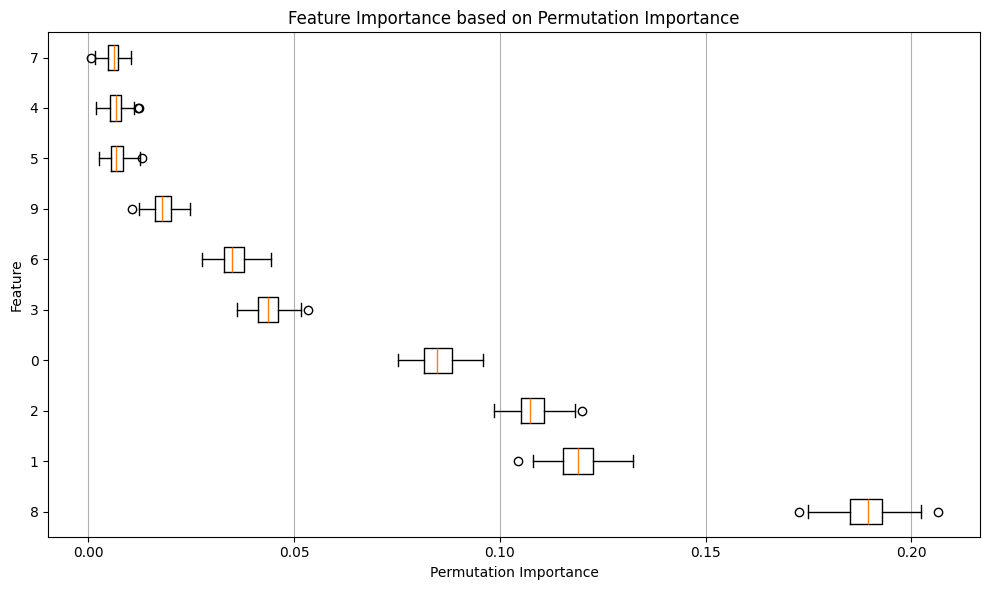

In [ ]:
from sklearn.utils import Bunch

rfc = RandomForestClassifier(oob_score=True, random_state=42)
rfc.fit(X_train, y_train)

prem_res = permutation_importance(rfc, X_test, y_test, n_repeats=20, random_state=42)
assert isinstance(prem_res, Bunch)

idx = np.argsort(prem_res.importances_mean)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance based on Permutation Importance")
plt.boxplot(prem_res.importances[idx].T, vert=False)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(1, X.shape[1] + 1), labels=list(idx))
plt.grid(axis="x")
plt.tight_layout()
plt.show()


# 模型训练

## 基础模型

Training Logistic Regression...

Done.

Training Decision Tree...

Done.

Training Support Vector Classifier...

...

Done.

Training Random Forest...

Done.

Training XGBoost...

Done.

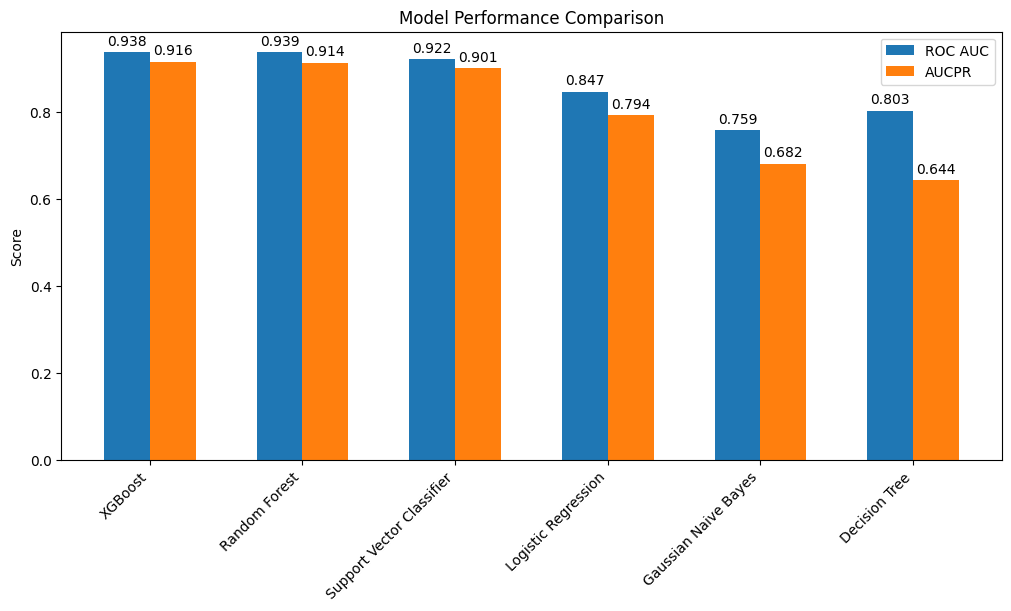

In [ ]:
models = [
    (LogisticRegression(random_state=42), "Logistic Regression"),
    (DecisionTreeClassifier(random_state=42), "Decision Tree"),
    (SVC(probability=True, random_state=42), "Support Vector Classifier"),
    (GaussianNB(), "Gaussian Naive Bayes"),
    (RandomForestClassifier(random_state=42), "Random Forest"),
    (XGBClassifier(random_state=42), "XGBoost"),
]

res = {}

for model, model_name in models:
    print(f"Training {model_name}...", end="\t")
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    res[model_name] = (
        roc_auc_score(y_test, y_pred),
        average_precision_score(y_test, y_pred, pos_label=1),
    )
    print("Done.")

df = pd.DataFrame.from_dict(res).T
df.columns = ["ROC_AUC", "AUCPR"]
df = df.sort_values(by="AUCPR", ascending=False)

plt_idx = np.arange(len(df))
width = 0.3

fig, ax = plt.subplots(layout="constrained", figsize=(10, 6))
ax.bar(plt_idx - width / 2, df["ROC_AUC"], label="ROC AUC", width=width)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.bar(plt_idx + width / 2, df["AUCPR"], label="AUCPR", width=width)
ax.bar_label(ax.containers[1], fmt="%.3f", padding=3)
ax.set_xticks(plt_idx)
ax.set_xticklabels(df.index, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()
plt.show()


## 调参

### 随机森林

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=2
)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

y_pred = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
res["Tuned Random Forest"] = (
    roc_auc_score(y_test, y_pred),
    average_precision_score(y_test, y_pred, pos_label=1),
)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

### XGBoost

In [ ]:
def try_xgb(model, folds=5, rounds=50):
    xgb_param = model.get_xgb_params()
    cv_res = xgb.cv(
        xgb_param,
        xgb.DMatrix(X_train, label=y_train),
        num_boost_round=model.get_params()["n_estimators"],
        nfold=folds,
        early_stopping_rounds=rounds,
    )

    model.set_params(n_estimators=cv_res.shape[0])
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred), average_precision_score(y_test, y_pred)


def search_xgb(params, grid):
    g = GridSearchCV(
        estimator=XGBClassifier(**params),
        param_grid=grid,
        scoring="roc_auc",
        n_jobs=4,
        cv=5,
    )
    g.fit(X_train, y_train)

    print(g.best_score_)
    return g.best_params_


In [ ]:
params = {
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "max_depth": 5,
    "min_child_weight": 1,
    "gamma": 0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "nthread": 4,
    "scale_pos_weight": 1,
    "seed": 42,
}

xgb1 = XGBClassifier(**params)
_, _ = try_xgb(xgb1)
xgb1.get_params()["n_estimators"]


255

In [ ]:
params["n_estimators"] = 255

search_xgb(params, {"max_depth": range(3, 10, 2), "min_child_weight": range(1, 6, 2)})


0.9352652961962604

{'max_depth': 5, 'min_child_weight': 1}

In [ ]:
params["max_depth"] = 5
params["min_child_weight"] = 1

search_xgb(params, {"gamma": np.linspace(0, 0.5, 10)})


0.9353035030472764

{'gamma': np.float64(0.3333333333333333)}

In [ ]:
params["gamma"] = 0.33

search_xgb(
    params,
    {
        "subsample": np.linspace(0.7, 1.0, 5),
        "colsample_bytree": np.linspace(0.7, 1.0, 5),
    },
)


0.9357393792805244

{'colsample_bytree': np.float64(0.925), 'subsample': np.float64(0.925)}

In [ ]:
params["colsample_bytree"] = 0.925
params["subsample"] = 0.925

search_xgb(params, {"reg_alpha": [1e-5, 1e-2, 0.1, 1, 100]})


c:\Users\oleander\Desktop\aml\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:58:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "subsamp" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.9362448610215315

{'reg_alpha': 0.1}

In [ ]:
params["reg_lambda"] = 0.1
params


{'learning_rate': 0.1,
 'n_estimators': 255,
 'max_depth': 5,
 'min_child_weight': 1,
 'gamma': 0.33,
 'subsample': 0.925,
 'colsample_bytree': 0.925,
 'objective': 'binary:logistic',
 'nthread': 4,
 'scale_pos_weight': 1,
 'seed': 42,
 'reg_alpha': 0.1,
 'reg_lambda': 0.1}

In [ ]:
for lr in np.linspace(0.02, 0.2, 20):
    params["learning_rate"] = lr
    params["n_estimators"] = 1000
    xgb2 = XGBClassifier(**params)
    aucroc, aucpr = try_xgb(xgb2)
    print(
        f"learning_rate = {lr:.2f}, n_estimators = {xgb2.get_params()['n_estimators']}, ROC AUC = {aucroc:.4f}, AUCPR = {aucpr:.4f}"
    )


learning_rate = 0.020, n_estimators = 1000, ROC AUC = 0.9437, AUCPR = 0.9233

learning_rate = 0.029, n_estimators = 846, ROC AUC = 0.9447, AUCPR = 0.9244

learning_rate = 0.039, n_estimators = 686, ROC AUC = 0.9435, AUCPR = 0.9234

learning_rate = 0.048, n_estimators = 510, ROC AUC = 0.9438, AUCPR = 0.9237

learning_rate = 0.058, n_estimators = 450, ROC AUC = 0.9439, AUCPR = 0.9238

...

learning_rate = 0.162, n_estimators = 164, ROC AUC = 0.9419, AUCPR = 0.9213

learning_rate = 0.172, n_estimators = 121, ROC AUC = 0.9426, AUCPR = 0.9218

learning_rate = 0.181, n_estimators = 126, ROC AUC = 0.9408, AUCPR = 0.9203

learning_rate = 0.191, n_estimators = 141, ROC AUC = 0.9431, AUCPR = 0.9219

learning_rate = 0.200, n_estimators = 124, ROC AUC = 0.9427, AUCPR = 0.9210

In [ ]:
params["learning_rate"] = 0.067
params["n_estimators"] = 418

best_xgb = XGBClassifier(**params)
aucroc, aucpr = try_xgb(best_xgb)

res["Tuned XGBoost"] = (aucroc, aucpr)


# 展示

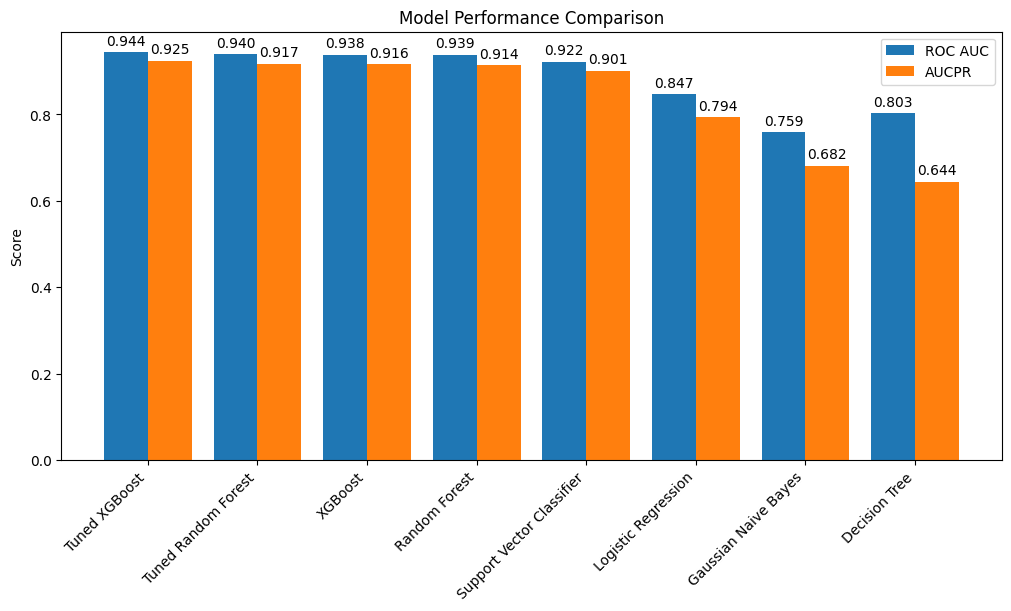

In [ ]:
df = pd.DataFrame.from_dict(res).T
df.columns = ["ROC_AUC", "AUCPR"]
df = df.sort_values(by="AUCPR", ascending=False)

plt_idx = np.arange(len(df))
width = 0.4

fig, ax = plt.subplots(layout="constrained", figsize=(10, 6))
ax.bar(plt_idx - width / 2, df["ROC_AUC"], label="ROC AUC", width=width)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.bar(plt_idx + width / 2, df["AUCPR"], label="AUCPR", width=width)
ax.bar_label(ax.containers[1], fmt="%.3f", padding=3)
ax.set_xticks(plt_idx)
ax.set_xticklabels(df.index, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()
plt.show()
